In [32]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path(__vsc_ipynb_file__).parent))  # add error_analysis/ to path

from ea_utils import load_analysis_data
import numpy as np
import pandas as pd

dev_df, true_labels, main_preds, base_preds = load_analysis_data()
print(f"Dev samples: {len(true_labels)}, PCL positive: {true_labels.sum()}")
print(f"Columns: {list(dev_df.columns)}")

Dev samples: 2093, PCL positive: 199
Columns: ['par_id', 'text', 'binary_label', 'keyword']


In [33]:
# Build analysis DataFrame
df = dev_df[["par_id", "keyword", "text", "binary_label"]].copy()
df["main_pred"]     = main_preds
df["base_pred"]     = base_preds
df["main_correct"]  = (main_preds == true_labels)
df["base_correct"]  = (base_preds == true_labels)

both_correct = df[ df["main_correct"] &  df["base_correct"]]   
both_wrong   = df[~df["main_correct"] & ~df["base_correct"]]   
main_only    = df[ df["main_correct"] & ~df["base_correct"]]   
base_only    = df[~df["main_correct"] &  df["base_correct"]]   

total = len(df)
print(f"{'Category':<35} {'Count':>6}  {'%':>6}")
print("-" * 50)
print(f"{'Both correct':<35} {len(both_correct):>6}  {len(both_correct)/total*100:>5.1f}%")
print(f"{'Both wrong':<35} {len(both_wrong):>6}  {len(both_wrong)/total*100:>5.1f}%")
print(f"{'Main correct, Baseline wrong':<35} {len(main_only):>6}  {len(main_only)/total*100:>5.1f}%")
print(f"{'Baseline correct, Main wrong':<35} {len(base_only):>6}  {len(base_only)/total*100:>5.1f}%")

Category                             Count       %
--------------------------------------------------
Both correct                          1873   89.5%
Both wrong                              97    4.6%
Main correct, Baseline wrong            67    3.2%
Baseline correct, Main wrong            56    2.7%


In [35]:
# FP / FN breakdown for main model
main_fp = df[(df["main_pred"] == 1) & (df["binary_label"] == 0)] 
main_fn = df[(df["main_pred"] == 0) & (df["binary_label"] == 1)] 

print(f"Main model — False Positives: {len(main_fp)}, False Negatives: {len(main_fn)}")
print()

# Keyword distribution in FP and FN
print("Keywords in False Positives (predicted PCL but wrong):")
print(main_fp["keyword"].value_counts().to_string())
print()
print("Keywords in False Negatives (missed PCL):")
print(main_fn["keyword"].value_counts().to_string())

Main model — False Positives: 78, False Negatives: 75

Keywords in False Positives (predicted PCL but wrong):
keyword
hopeless         13
vulnerable       13
in-need          11
homeless         11
refugee          11
poor-families    10
women             4
disabled          3
migrant           1
immigrant         1

Keywords in False Negatives (missed PCL):
keyword
poor-families    22
hopeless         11
homeless         10
women             8
disabled          7
refugee           5
immigrant         4
vulnerable        4
in-need           3
migrant           1


In [36]:
from ea_utils import PROJECT_ROOT

OUT_FILE = PROJECT_ROOT / "error_analysis" / "error_examples.txt"

def show_samples(subset, title, n=5, fout=None):
    header = f"\n{'='*70}\n  {title}  (total={len(subset)})\n{'='*70}"
    print(header)
    if fout: fout.write(header + "\n")

    for label_val, label_name in [(1, "TRUE=PCL"), (0, "TRUE=NON-PCL")]:
        group = subset[subset["binary_label"] == label_val].head(n)
        for _, row in group.iterrows():
            line1 = f"[{label_name}] keyword={row['keyword']} | main={row['main_pred']} base={row['base_pred']}"
            line2 = f"  {row['text'][:300]}"
            print(line1)
            print(line2)
            print()
            if fout:
                fout.write(line1 + "\n" + line2 + "\n\n")

with open(OUT_FILE, "w", encoding="utf-8") as fout:
    show_samples(both_wrong, "Both Wrong", n=4, fout=fout)
    show_samples(main_only,  "Main Correct, Baseline Wrong", n=4, fout=fout)
    show_samples(base_only,  "Baseline Correct, Main Wrong", n=4, fout=fout)

print(f"Saved to {OUT_FILE}")


  Both Wrong  (total=97)
[TRUE=PCL] keyword=homeless | main=0 base=0
  His present " chambers " may be quite humble , but Shiyani has the tiny space very neatly organized and clean . Many people pass him by but do not manage to see him , because the space is partially hidden behind trees , which gives him a relative privacy . " There are many homeless sleeping around t

[TRUE=PCL] keyword=disabled | main=0 base=0
  Krueger recently harnessed that creativity to self-publish a book featuring the poems , artwork , photography and short stories of 16 ill or disabled artists from around the world . She hopes the book , which contains some of her own work as well , will show how talented disabled people can be .

[TRUE=PCL] keyword=poor-families | main=0 base=0
  10:41am - Parents of children who died must get compensation , free medicine must be provided to poor families across UP : Ram Gopal Yadav

[TRUE=PCL] keyword=poor-families | main=0 base=0
  We are alarmed to learn of your recently

      keyword   n  n_pos  f1_main  f1_base
poor-families 190     38 0.500000 0.421053
        women 233     14 0.500000 0.333333
      refugee 188     13 0.500000 0.380952
    immigrant 218      7 0.545455 0.250000
     hopeless 217     26 0.555556 0.392157
     disabled 194     14 0.583333 0.636364
     homeless 212     29 0.644068 0.444444
   vulnerable 209     20 0.653061 0.611111
      migrant 206      5 0.800000 0.571429
      in-need 226     33 0.810811 0.707692


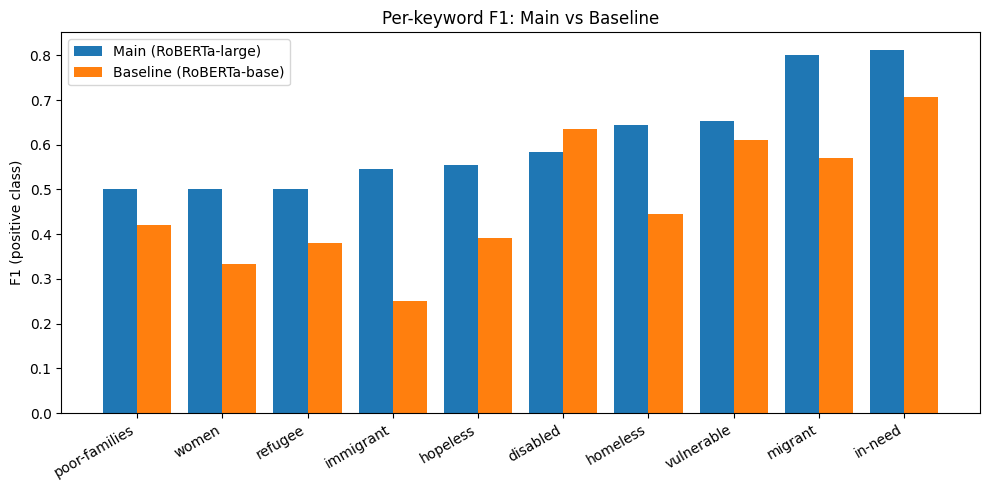

In [37]:
import matplotlib.pyplot as plt

# Keyword-level F1 for main model
keywords = df["keyword"].unique()
rows = []
for kw in keywords:
    sub = df[df["keyword"] == kw]
    if len(sub) == 0:
        continue
    from sklearn.metrics import f1_score
    f1_main = f1_score(sub["binary_label"], sub["main_pred"], average="binary", pos_label=1, zero_division=0)
    f1_base = f1_score(sub["binary_label"], sub["base_pred"], average="binary", pos_label=1, zero_division=0)
    n_pos = sub["binary_label"].sum()
    rows.append({"keyword": kw, "n": len(sub), "n_pos": n_pos, "f1_main": f1_main, "f1_base": f1_base})

kw_df = pd.DataFrame(rows).sort_values("f1_main")
print(kw_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(kw_df))
ax.bar([i - 0.2 for i in x], kw_df["f1_main"], width=0.4, label="Main (RoBERTa-large)")
ax.bar([i + 0.2 for i in x], kw_df["f1_base"], width=0.4, label="Baseline (RoBERTa-base)")
ax.set_xticks(list(x))
ax.set_xticklabels(kw_df["keyword"], rotation=30, ha="right")
ax.set_ylabel("F1 (positive class)")
ax.set_title("Per-keyword F1: Main vs Baseline")
ax.legend()
plt.tight_layout()
plt.savefig("keyword_f1.png", dpi=150)
plt.show()
